In [27]:
import numpy as np
import pandas as pd
import os
import json
import pathlib
from scipy.stats import gaussian_kde
from tqdm import tqdm
import warnings
import seaborn as sns
from skimage import util
from skimage.filters import threshold_otsu, gaussian, threshold_isodata, threshold_minimum, threshold_triangle, threshold_otsu, threshold_mean, threshold_li, try_all_threshold, threshold_yen, threshold_multiotsu
from skimage.segmentation import clear_border, watershed, expand_labels
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, opening, ball, dilation, erosion
from skimage.transform import rescale
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from scipy import stats as _stats
from matplotlib.colors import to_hex
from skimage.filters import median as median_filter
from skimage.morphology import square
from tifffile import imread
import tifffile
import liffile
import napari
from napari.utils.colormaps import DirectLabelColormap
import colorsys
from collections import defaultdict
from skimage.morphology import closing, disk
import contextlib
import joblib
from joblib import Parallel, delayed
from PIL import ImageColor

warnings.filterwarnings("ignore")

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [28]:
def create_n_valued_palette(base_colour_hex, n=5):
    r, g, b = ImageColor.getcolor(base_colour_hex, "RGB")
    r, g, b = r/255, g/255, b/255
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    adjustments = np.linspace(0.5, 1.4, n)
    palette = []
    for a in adjustments:
        l_adj = min(max(l * a, 0), 1)
        rgb = colorsys.hls_to_rgb(h, l_adj, s)
        palette.append(to_hex(rgb))
    return palette

# Default palette: add/change entries here to introduce new groups
DEFAULT_PALETTE = {
    "ARi": "#FF8C00",
    "UTD": "#000000",
}

In [74]:
def add_experiment_info(df):
    """Extract patient, day, and flow from the image name column (vectorised)."""
    name = df["image"].astype(str).str.lower() + df["lif_file"].astype(str).str.lower()

    df["patient"] = np.where(name.str.contains("fl32"), "fl32",
                   np.where(name.str.contains("fl12"), "fl12", "unknown"))

    df["day"] = np.where(name.str.contains("day6"), "6",
               np.where(name.str.contains("day7"), "7",
               np.where(name.str.contains("day9"), "9", "unknown")))

    df["flow"] = np.where(name.str.contains("3mm"), "3mm",
                np.where(name.str.contains("7mm"), "7mm", "unknown"))
    df["fixation"] = np.where(name.str.contains("fix"), "fixed",
     "live")

    return df

In [ ]:
# Canonical regions used throughout
REGIONS = ["chip", "not_chip", "tumour", "chip_not_tumour",
           "chip_vasculature", "chip_not_vasculature", "left", "right"]

def count_cells(region_mask, crow, ccol):
    """Count how many cell centroids (crow, ccol) fall inside region_mask."""
    if len(crow) == 0:
        return 0
    return int(region_mask[crow, ccol].sum())


In [85]:
# ── Label channel convention ──────────────────────────────────────────────────
# Combined TIF layout: (9, Y, X) float32
#   Channels 0–3: raw projection  (B cells, Vasculature, Brightfield, CART)
#   Channel  4: chip        (1 = on-chip region)
#   Channel  5: vasculature (1 = vasculature)
#   Channel  6: b_cells     (1 = B cell)
#   Channel  7: cart_cells  (1 = CART cell)
#   Channel  8: tumour      (1 = tumour)
N_RAW_CHANNELS = 4
LABEL_NAMES = ["chip", "vasculature", "b_cells", "cart_cells", "tumour"]

GAUSS_SIGMAS_UM    = [5, 10, 20, 50, 100]
PROXIMITY_RADII_UM = [5, 10, 20, 30, 40, 50, 100]


def _safe_name(img_name):
    return img_name.replace("/", "_").replace("\\", "_")


def _segment_chip(max_projection):
    """Segment the chip region from the brightfield channel. Returns chip (bool), smoothed."""
    brightfield = max_projection[2]
    clipped = np.clip(brightfield, np.percentile(brightfield, 25), np.percentile(brightfield, 90))
    smoothed = gaussian(clipped, sigma=7)
    bright = smoothed > threshold_li(smoothed)
    labelled_bright = label(bright)
    h = smoothed.shape[0]

    left_labels = set(labelled_bright[:, 0]) - {0}
    left_region = np.isin(labelled_bright, list(left_labels))
    left_region = closing(left_region, disk(10))
    left_region = remove_small_holes(left_region, max_size=500000)

    right_labels = set(labelled_bright[:, -1]) - {0}
    right_region = np.isin(labelled_bright, list(right_labels))
    right_region = closing(right_region, disk(10))
    right_region = remove_small_holes(right_region, max_size=500000)

    if left_region[:, 0].sum() > h / 2:
        bright_mean = smoothed > threshold_mean(smoothed)
        lbl_mean = label(bright_mean)
        ll = set(lbl_mean[:, 0]) - {0}
        left_region = np.isin(lbl_mean, list(ll))
        left_region = closing(left_region, disk(10))
        left_region = remove_small_holes(left_region, max_size=500000)

    if right_region[:, -1].sum() > h / 2:
        bright_mean = smoothed > threshold_mean(smoothed)
        lbl_mean = label(bright_mean)
        rl = set(lbl_mean[:, -1]) - {0}
        right_region = np.isin(lbl_mean, list(rl))
        right_region = closing(right_region, disk(10))
        right_region = remove_small_holes(right_region, max_size=500000)

    chip = (~left_region & ~right_region).astype(bool)
    return chip, smoothed


def _segment_tumour(smoothed, chip):
    """Segment the tumour from the smoothed brightfield, restricted to chip."""
    img_center = np.array([smoothed.shape[0] / 2, smoothed.shape[1] / 2])

    def _best_tumour(lbl_img):
        props = pd.DataFrame(regionprops_table(
            lbl_img, properties=("label", "area", "perimeter", "centroid")))
        props = props[props["area"] >= 0.01 * lbl_img.size] if not props.empty else props
        if props.empty:
            return None
        circ = (4 * np.pi * props["area"]) / (props["perimeter"] ** 2 + 1e-9)
        dist = np.hypot(props["centroid-0"] - img_center[0], props["centroid-1"] - img_center[1])
        props["score"] = props["area"] * circ / (1 + dist)
        return int(props.loc[props["score"].idxmax(), "label"])

    tumour_raw = (smoothed < threshold_triangle(smoothed)) & chip
    lbl = label(tumour_raw)
    chosen = _best_tumour(lbl)
    tumour = (lbl == chosen) if chosen is not None else tumour_raw

    tumour_rp = regionprops(label(tumour))
    if tumour_rp and tumour_rp[0].solidity < 0.9:
        eroded = erosion(tumour, disk(10))
        e_lbl = label(eroded)
        chosen_e = _best_tumour(e_lbl)
        if chosen_e is not None:
            tumour = (expand_labels(e_lbl, distance=10) == chosen_e)

        tumour_rp = regionprops(label(tumour))
        if tumour_rp and tumour_rp[0].solidity < 0.9:
            eroded = erosion(tumour, disk(50))
            e_lbl = label(eroded)
            chosen_e = _best_tumour(e_lbl)
            if chosen_e is not None:
                tumour = (expand_labels(e_lbl, distance=60) == chosen_e)

    # Watershed: split tumour into ≤2 sub-regions, keep the darkest
    tumour_mask = tumour.astype(bool)
    tumour_mask = remove_small_holes(tumour_mask, max_size=500000)
    tumour_pixels = smoothed[tumour_mask]
    if tumour_pixels.size > 0:
        smooth_for_ws = gaussian(smoothed, sigma=10)
        edt_tumour = distance_transform_edt(tumour_mask)
        coords = peak_local_max(edt_tumour, min_distance=60,
                                labels=tumour_mask.astype(int), num_peaks=2)
        if len(coords) >= 2:
            markers = np.zeros_like(tumour_mask, dtype=int)
            for i, (r, c) in enumerate(coords, start=1):
                markers[r, c] = i
            ws_labels = watershed(smooth_for_ws, markers, mask=tumour_mask)
            ws_medians = {}
            for lbl_val in np.unique(ws_labels[ws_labels > 0]):
                ws_medians[lbl_val] = float(np.median(smoothed[ws_labels == lbl_val]))
            darkest_label = min(ws_medians, key=ws_medians.get)
            tumour = (ws_labels == darkest_label)
        else:
            tumour = tumour_mask

    return tumour.astype(bool)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1: Segment and save combined raw + labels as a single TIF
# ══════════════════════════════════════════════════════════════════════════════
def segment_and_save(img, output_dir, lif_path=None):
    """Project to 2D, auto-segment, save raw + labels in a single (9,Y,X) TIF."""
    output_dir = pathlib.Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)
    safe = _safe_name(img.name)

    lif_stem = lif_path.stem if lif_path else ""
    combined_name = (img.name + lif_stem).lower()
    meta = {
        "image_name": img.name,
        "lif_file": lif_stem,
        "patient": "fl32" if "fl32" in combined_name else "fl12" if "fl12" in combined_name else "unknown",
        "day": "6" if "day6" in combined_name else "7" if "day7" in combined_name else "unknown",
    }

    # Max projection
    max_projection = np.max(img.asarray(), axis=img.dims.index('Z'))  # (C, Y, X)

    # Pixel size
    try:
        x_coords = img.coords["X"]
        um_per_px = abs(float(x_coords[1] - x_coords[0])) * 1e6
        if um_per_px <= 0:
            raise ValueError
    except Exception:
        um_per_px = 1.0
        warnings.warn(f"Could not read pixel size for {img.name}, using 1 µm/px")
    meta["um_per_px"] = um_per_px

    # Cell segmentation (binary)
    bcells_raw = max_projection[0]
    cart_raw = max_projection[-1]
    seg_b = (bcells_raw > threshold_yen(bcells_raw)).astype(np.uint8)
    seg_cart = (cart_raw > threshold_yen(cart_raw)).astype(np.uint8)

    # Vasculature
    vasc_raw = max_projection[1]
    vasc_med = median_filter(vasc_raw, footprint=square(7))
    vasc_sm = gaussian(vasc_med, sigma=3)
    seg_vasc = vasc_sm > threshold_triangle(vasc_sm)
    lbl_vasc = label(seg_vasc)
    rp = pd.DataFrame(regionprops_table(lbl_vasc, properties=("area", "solidity")))
    if float(rp.loc[rp["area"].idxmax(), "solidity"]) > 0.9:
        seg_vasc = vasc_sm > threshold_li(vasc_sm)
    seg_vasc = seg_vasc.astype(np.uint8)

    # Chip
    chip, smoothed = _segment_chip(max_projection)
    seg_chip = chip.astype(np.uint8)

    # Tumour
    seg_tumour = _segment_tumour(smoothed, chip).astype(np.uint8)

    # Stack labels: (5, Y, X) — chip, vasculature, b_cells, cart_cells, tumour
    labels = np.stack([seg_chip, seg_vasc, seg_b, seg_cart, seg_tumour], axis=0)

    # Combine raw + labels into single (9, Y, X) float32 TIF
    combined = np.concatenate([
        max_projection.astype(np.float32),
        labels.astype(np.float32),
    ], axis=0)

    tifffile.imwrite(str(output_dir / f"{safe}.tif"),
                     combined, imagej=True,
                     metadata={'Info': json.dumps(meta)})

    print(f"  Saved: {safe}")
    return safe


def _load_combined_tif(path):
    """Load a combined TIF → (raw, labels, meta_json_str).
    raw: (4, Y, X) float32,  labels: (5, Y, X) uint8,  meta_json_str: str or None.
    """
    with tifffile.TiffFile(str(path)) as tif:
        data = tif.asarray()  # (9, Y, X)
        ij = tif.imagej_metadata or {}
        info_str = ij.get('Info', None)
    raw = data[:N_RAW_CHANNELS]
    labels = data[N_RAW_CHANNELS:].astype(np.uint8)
    return raw, labels, info_str


def _save_combined_tif(path, raw, labels, info_str=None):
    """Re-save a combined TIF from raw + labels arrays."""
    combined = np.concatenate([
        raw.astype(np.float32),
        labels.astype(np.float32),
    ], axis=0)
    meta = {'Info': info_str} if info_str else {}
    tifffile.imwrite(str(path), combined, imagej=True, metadata=meta)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2: Open all images + labels in Napari for manual correction
# ══════════════════════════════════════════════════════════════════════════════
LABEL_COLORMAPS = {
    "chip":        DirectLabelColormap(color_dict={0: "transparent", 1: "cyan"}),
    "vasculature": DirectLabelColormap(color_dict={0: "transparent", 1: "magenta"}),
    "b_cells":     DirectLabelColormap(color_dict={0: "transparent", 1: "green"}),
    "cart_cells":  DirectLabelColormap(color_dict={0: "transparent", 1: "red"}),
    "tumour":      DirectLabelColormap(color_dict={0: "transparent", 1: "yellow"}),
}

def review_in_napari(label_dir):
    """Load ONE image at a time into Napari for editing.

    Returns (viewer, controls) where controls has .next(), .prev(), .save(), .goto(i).
    Only the current image's layers are in memory at any time.
    """
    from magicgui import magicgui
    from napari._qt.qthreading import thread_worker
    label_dir = pathlib.Path(label_dir)

    # Discover all combined TIFs (exclude QC PNGs etc.)
    image_list = sorted(label_dir.glob("*.tif"))
    if not image_list:
        print("No images found in", label_dir)
        return None, None

    viewer = napari.Viewer()
    state = {"idx": 0, "label_layers": {}, "raw": None, "labels": None,
             "dirty": False, "meta_info": None}

    CH_NAMES = ["B cells (raw)", "Vasculature (raw)", "Brightfield", "CART (raw)"]
    EDITABLE_LABELS = ["chip", "tumour"]  # only these get viewer layers

    def _save_current():
        if not state["label_layers"] or state["labels"] is None:
            return
        tif_path = image_list[state["idx"]]
        updated = state["labels"].copy()
        for lname, layer in state["label_layers"].items():
            li = LABEL_NAMES.index(lname)
            updated[li] = (layer.data > 0).astype(np.uint8)
        _save_combined_tif(tif_path, state["raw"], updated, state["meta_info"])
        state["labels"] = updated
        state["dirty"] = False
        print(f"  Saved: {tif_path.name}")

    def _load_image(idx):
        """Clear viewer and load image at index idx."""
        if state["dirty"]:
            _save_current()

        state["label_layers"] = {}
        viewer.layers.clear()

        tif_path = image_list[idx]
        state["idx"] = idx
        safe = tif_path.stem

        raw, labels, info_str = _load_combined_tif(tif_path)
        state["raw"] = raw
        state["labels"] = labels.copy()
        state["meta_info"] = info_str

        # Raw channels (not editable)
        for ci in range(raw.shape[0]):
            name = CH_NAMES[ci] if ci < len(CH_NAMES) else f"Ch{ci}"
            viewer.add_image(raw[ci], name=name,
                             visible=(ci == 2), blending="additive")

        # Editable label layers (chip + tumour only)
        for lname in EDITABLE_LABELS:
            li = LABEL_NAMES.index(lname)
            layer = viewer.add_labels(
                labels[li],
                name=lname,
                colormap=LABEL_COLORMAPS.get(lname),
            )
            state["label_layers"][lname] = layer

        viewer.title = f"[{idx + 1}/{len(image_list)}] {safe}"
        state["dirty"] = True
        print(f"Loaded [{idx + 1}/{len(image_list)}]: {safe}")

    def _fn_save():
        _save_current()

    def _fn_next():
        if state["idx"] < len(image_list) - 1:
            _load_image(state["idx"] + 1)
        else:
            print("Already at last image.")

    def _fn_prev():
        if state["idx"] > 0:
            _load_image(state["idx"] - 1)
        else:
            print("Already at first image.")

    def _fn_goto(i):
        if 0 <= i < len(image_list):
            _load_image(i)
        else:
            print(f"Index {i} out of range (0–{len(image_list)-1})")

    def _fn_reset_label(name):
        """Replace a label layer with a fresh blank one."""
        if name not in EDITABLE_LABELS:
            print(f"Unknown label '{name}'. Choose from: {EDITABLE_LABELS}")
            return
        old_layer = state["label_layers"][name]
        shape = old_layer.data.shape

        viewer.layers.remove(old_layer)

        blank = np.zeros(shape, dtype=old_layer.data.dtype)
        new_layer = viewer.add_labels(
            blank,
            name=name,
            colormap=LABEL_COLORMAPS.get(name),
        )
        state["label_layers"][name] = new_layer
        state["dirty"] = True
        print(f"  Reset '{name}' to blank. Paint with value 1 to redraw.")

    # Keyboard shortcuts
    @viewer.bind_key("n")
    def _key_next(viewer):
        _fn_next()

    @viewer.bind_key("b")
    def _key_prev(viewer):
        _fn_prev()

    @viewer.bind_key("Control-s")
    def _key_save(viewer):
        _fn_save()

    # Reset-label button (docked in viewer)
    @magicgui(
        call_button="Reset Label",
        label_name={"choices": EDITABLE_LABELS, "label": "Label to reset"},
    )
    def reset_widget(label_name=EDITABLE_LABELS[0]):
        _fn_reset_label(label_name)

    viewer.window.add_dock_widget(reset_widget, name="Reset Label", area="right")

    # Load first image
    _load_image(0)
    print(f"\n{len(image_list)} images found. Shortcuts: n=next, b=back, Ctrl+S=save")
    print("Labels auto-save when you navigate to the next/prev image.")

    class _Controls:
        """Returned handle for programmatic navigation."""
        next = staticmethod(_fn_next)
        prev = staticmethod(_fn_prev)
        save = staticmethod(_fn_save)
        goto = staticmethod(_fn_goto)
        reset_label = staticmethod(_fn_reset_label)
        n_images = len(image_list)

    return viewer, _Controls()


# ── QC figure: show segmented regions overlaid on their source channel ───────
OVERLAY_COLORS = {
    "Chip":           [0, 1, 1, 0.35],      # cyan
    "Tumour":         [1, 1, 0, 0.45],      # yellow
    "Vasculature":    [1, 0, 1, 0.40],      # magenta
    "CART cells":     [1, 0, 0, 0.45],      # red
    "B cells":        [0, 1, 0, 0.45],      # green
}

def save_output_figure(img_name, panels, out_dir):
    """Save a 2-row QC figure.
    panels: list of (title, raw_channel, mask) tuples.
    Top row = raw channel (gray), bottom row = mask overlaid in colour."""
    n = len(panels)
    fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(4 * n, 7), constrained_layout=True)
    fig.suptitle(f"Segmentation — {img_name}", fontsize=11, fontweight="bold")
    for col, (title, raw_ch, mask) in enumerate(panels):
        axes[0, col].imshow(raw_ch, cmap="gray", interpolation="none")
        axes[0, col].set_title(title, fontsize=9)
        axes[0, col].axis("off")
        axes[1, col].imshow(raw_ch, cmap="gray", interpolation="none")
        overlay = np.zeros((*raw_ch.shape, 4), dtype=float)
        color = OVERLAY_COLORS.get(title, [1, 0.2, 0.2, 0.5])
        overlay[mask, :] = color
        axes[1, col].imshow(overlay, interpolation="none")
        axes[1, col].set_title(f"{title} mask", fontsize=8)
        axes[1, col].axis("off")
    safe = img_name.replace('/', '_').replace('\\', '_')
    out_path = out_dir / f"{safe}_segmentations.png"
    fig.savefig(out_path, dpi=100, bbox_inches="tight")
    plt.close(fig)
    return out_path


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3: Analyse from corrected labels (parallelised)
# ══════════════════════════════════════════════════════════════════════════════
def _analyse_one_image(tif_path, output_folder=None):
    """Analyse a single combined TIF. Returns (records_df, dists_df, coloc_df)."""
    raw, labels_arr, info_str = _load_combined_tif(tif_path)
    meta = json.loads(info_str) if info_str else {}
    um_per_px = meta.get("um_per_px", 1.0)

    # Unpack label channels
    chip     = labels_arr[0].astype(bool)
    vasc     = labels_arr[1].astype(bool)
    seg_b    = labels_arr[2].astype(bool)
    seg_cart = labels_arr[3].astype(bool)
    tumour   = labels_arr[4].astype(bool)

    # Recompute left/right from chip
    not_chip = ~chip
    lbl_nc = label(not_chip)
    left_mask = np.zeros_like(chip)
    right_mask = np.zeros_like(chip)
    for rp in regionprops(lbl_nc):
        coords = rp.coords  # (N, 2) — row, col
        if np.any(coords[:, 1] == 0):
            left_mask[lbl_nc == rp.label] = True
        if np.any(coords[:, 1] == chip.shape[1] - 1):
            right_mask[lbl_nc == rp.label] = True

    # Build regions dict
    regions = {
        "chip":                 chip,
        "not_chip":             not_chip,
        "tumour":               chip & tumour,
        "chip_not_tumour":      chip & ~tumour,
        "chip_vasculature":     chip & vasc,
        "chip_not_vasculature": chip & ~vasc,
        "left":                 left_mask.astype(bool),
        "right":                right_mask.astype(bool),
    }

    dist_from_tumour = distance_transform_edt(~tumour)
    safe = tif_path.stem
    img_name = meta.get("image_name", safe)
    m = {k: meta.get(k, "unknown") for k in ("lif_file", "patient", "day")}

    # Counting
    records, dist_records = [], []
    for cell_name, cell_mask in [("CART cells", seg_cart), ("B cells", seg_b)]:
        labelled_cells = label(cell_mask)
        total_cells = int(labelled_cells.max())
        total_pixels = int(cell_mask.sum())

        if total_cells > 0:
            cprops = pd.DataFrame(regionprops_table(labelled_cells, properties=("centroid",)))
            crow = np.clip(np.round(cprops["centroid-0"].values).astype(int),
                           0, cell_mask.shape[0] - 1)
            ccol = np.clip(np.round(cprops["centroid-1"].values).astype(int),
                           0, cell_mask.shape[1] - 1)
        else:
            crow = np.array([], dtype=int)
            ccol = np.array([], dtype=int)

        records.append(dict(**m, image=img_name, cell_type=cell_name,
                            region="overall", cell_count=total_cells,
                            positive_pixels=total_pixels))
        for rname, rmask in regions.items():
            n_cells = count_cells(rmask, crow, ccol)
            n_px = int(np.sum(cell_mask & rmask))
            records.append(dict(**m, image=img_name, cell_type=cell_name,
                                region=rname, cell_count=n_cells,
                                positive_pixels=n_px))

        if total_cells > 0:
            dists = dist_from_tumour[crow, ccol] * um_per_px
            for r, c, d in zip(crow, ccol, dists):
                rec = dict(**m, image=img_name, cell_type=cell_name,
                           distance_from_tumour_um=float(d))
                for rname, rmask in regions.items():
                    rec[f"in_{rname}"] = bool(rmask[r, c])
                dist_records.append(rec)

    # Colocalisation
    bcell_float = raw[0].astype(float)
    cart_float = raw[-1].astype(float)
    coloc_records = []
    for sigma_um in GAUSS_SIGMAS_UM:
        sigma_px = sigma_um / um_per_px
        b_blur = gaussian(bcell_float, sigma=sigma_px)
        c_blur = gaussian(cart_float, sigma=sigma_px)
        for rname, rmask in regions.items():
            bv, cv = b_blur[rmask], c_blur[rmask]
            r_val = np.nan if len(bv) < 20 else float(_stats.pearsonr(bv, cv)[0])
            coloc_records.append(dict(**m, image=img_name, method="coarse_pearson",
                                      param_um=sigma_um, region=rname, score=r_val))

    cart_edt = distance_transform_edt(~seg_cart)
    b_edt = distance_transform_edt(~seg_b)
    for radius_um in PROXIMITY_RADII_UM:
        radius_px = radius_um / um_per_px
        cart_within = cart_edt <= radius_px
        b_within = b_edt <= radius_px
        for rname, rmask in regions.items():
            b_in = seg_b & rmask;  n_b = int(b_in.sum())
            c_in = seg_cart & rmask; n_c = int(c_in.sum())
            frac_b = float((b_in & cart_within).sum()) / n_b if n_b else np.nan
            frac_c = float((c_in & b_within).sum()) / n_c if n_c else np.nan
            coloc_records.append(dict(**m, image=img_name, method="B_near_CART",
                                      param_um=radius_um, region=rname, score=frac_b))
            coloc_records.append(dict(**m, image=img_name, method="CART_near_B",
                                      param_um=radius_um, region=rname, score=frac_c))

    # ── QC overlay figure ─────────────────────────────────────────────────────
    if output_folder is not None:
        panels = [
            ("Chip",           raw[2],  chip),
            ("Tumour",         raw[2],  tumour),
            ("Vasculature",    raw[1],  vasc),
            ("CART cells",     raw[-1], seg_cart),
            ("B cells",        raw[0],  seg_b),
        ]
        save_output_figure(img_name, panels, pathlib.Path(output_folder))

    return pd.DataFrame(records), pd.DataFrame(dist_records), pd.DataFrame(coloc_records)


def analyse_from_labels(label_dir, output_folder, n_jobs=4):
    """Load corrected combined TIFs, run counting + colocalisation in parallel."""
    label_dir = pathlib.Path(label_dir)
    output_folder = pathlib.Path(output_folder)
    output_folder.mkdir(exist_ok=True, parents=True)

    tif_files = sorted(label_dir.glob("*.tif"))

    with tqdm_joblib(tqdm(desc="Analysing corrected labels", total=len(tif_files))) as pbar:
        results = Parallel(n_jobs=n_jobs, prefer="threads")(
            delayed(_analyse_one_image)(tp, output_folder) for tp in tif_files
        )

    all_records = [r[0] for r in results]
    all_dists   = [r[1] for r in results]
    all_coloc   = [r[2] for r in results]

    all_results = pd.concat(all_records, ignore_index=True)
    all_distances = pd.concat(all_dists, ignore_index=True)
    coloc_df = pd.concat(all_coloc, ignore_index=True)

    all_results.to_csv(output_folder / "all_counts.csv", index=False)
    all_distances.to_csv(output_folder / "all_distances.csv", index=False)
    coloc_df.to_csv(output_folder / "all_colocalisation.csv", index=False)

    return all_results, all_distances, coloc_df

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Segment all images and save raw + labels + metadata
# ══════════════════════════════════════════════════════════════════════════════
lif_folder = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel")
label_dir = lif_folder / "labels"

lif_files = sorted(lif_folder.glob("*.lif"))
print(f"Found {len(lif_files)} LIF files in {lif_folder}")
for lf in lif_files:
    print(f"  {lf.name}")

# Build task list
tasks = []
for lif_path in lif_files:
    with liffile.LifFile(lif_path) as lif:
        print(f"  {lif_path.name}: {len(lif.images)} images")
        for idx in range(len(lif.images)):
            tasks.append((lif_path, idx))

def _process_one(lif_path, img_idx):
    with liffile.LifFile(lif_path) as lif:
        img = lif.images[img_idx]
        return segment_and_save(img, label_dir, lif_path=lif_path)

with tqdm_joblib(tqdm(desc="Segmenting images", total=len(tasks))) as pbar:
    results = Parallel(n_jobs=4, prefer="threads")(
        delayed(_process_one)(lif_path, idx) for lif_path, idx in tasks
    )

print(f"\nAll labels saved to: {label_dir}")

Found 3 LIF files in Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel
  2026.04.01_CART.lif
  2026.04.04_CART.lif
  CART_fixed_day8_9.lif
  2026.04.01_CART.lif: 28 images
  2026.04.04_CART.lif: 16 images
  CART_fixed_day8_9.lif: 7 images


Segmenting images:   2%|▏         | 1/51 [00:53<44:45, 53.71s/it]

  Saved: Day6_Plate2_UTD_7mm_Merged


Segmenting images:   4%|▍         | 2/51 [02:37<1:07:44, 82.96s/it]

  Saved: Day6_Plate2_ARi_7mm_Merged


...

  Saved: Day9_Plate3_UTD_7mm_Merged


Segmenting images:  98%|█████████▊| 50/51 [21:20<00:21, 21.45s/it]

  Saved: Day9_Plate3_ARi_7mm_Merged


Segmenting images: 100%|██████████| 51/51 [23:00<00:00, 27.07s/it]

  Saved: Day9_Plate3_UTD_3mm_Merged

All labels saved to: Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\labels


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Open labels in Napari, edit, then save
# ══════════════════════════════════════════════════════════════════════════════
# Loads ONE image at a time to avoid freezing.
# Shortcuts: n = next image, b = previous image, Ctrl+S = save current
# Labels auto-save when you navigate to the next/prev image.
# You can also call:  controls.next()  controls.prev()  controls.save()  controls.goto(i)

label_dir = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\labels")
viewer, controls = review_in_napari(label_dir)

Loaded [1/51]: Day6_Plate2_ARi_3mm_Merged

51 images found. Shortcuts: n=next, b=back, Ctrl+S=save
Labels auto-save when you navigate to the next/prev image.


  Reset 'tumour' to blank. Paint with value 1 to redraw.
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day6_Plate2_ARi_3mm_Merged_labels.tif
Loaded [2/51]: Day6_Plate2_ARi_7mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day6_Plate2_ARi_7mm_Merged_labels.tif
Loaded [3/51]: Day6_Plate2_UTD_3mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day6_Plate2_UTD_3mm_Merged_labels.tif
Loaded [4/51]: Day6_Plate2_UTD_7mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day6_Plate2_UTD_7mm_Merged_labels.tif
Loaded [5/51]: Day7_Plate1_ARi_3mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day7_Plate1_ARi_3mm_Merged_labels.tif
Loaded [6/51]: Day7_Plate1_ARi_7mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day7_Plate1_ARi_7mm_Merged_labels.tif
Loaded [7/51]: Day7_Plate1_UTD_3mm_Merged
  Saved: Day7_Plate1_UTD_3mm_Merged_labels.tif
Loaded [8/51]: Day7_Plate1_UTD_7

In [ ]:
controls.prev()

  Saved: Day8_Plate6_UTD_3mm_Merged_labels.tif
Loaded [30/51]: Day8_Plate6_ARi_7mm_Merged


  Saved: Day8_Plate6_ARi_7mm_Merged_labels.tif
Loaded [31/51]: Day8_Plate6_UTD_3mm_Merged
  Saved: Day8_Plate6_UTD_3mm_Merged_labels.tif
Loaded [32/51]: Day8_Plate6_UTD_7mm_Merged
  Saved: Day8_Plate6_UTD_7mm_Merged_labels.tif
Loaded [33/51]: Day9_Plate1_ARi_3mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day9_Plate1_ARi_3mm_Merged_labels.tif
Loaded [34/51]: Day9_Plate1_ARi_7mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day9_Plate1_ARi_7mm_Merged_labels.tif
Loaded [35/51]: Day9_Plate1_UTD_3mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day9_Plate1_UTD_3mm_Merged_labels.tif
Loaded [36/51]: Day9_Plate1_UTD_7mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day9_Plate1_UTD_7mm_Merged_labels.tif
Loaded [37/51]: Day9_Plate2_ARi_3mm_Merged
  Reset 'chip' to blank. Paint with value 1 to redraw.
  Saved: Day9_Plate2_ARi_3mm_Merged_labels.tif
Loaded [38/51]: Day9_Plate2_ARi_7mm_Merged
  Res

In [18]:
# Save the current image's labels (also happens automatically when navigating)
controls.save()

  Saved: Day9_Plate5_UTD_7mm_Merged_labels.tif


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Analyse from corrected labels
# ══════════════════════════════════════════════════════════════════════════════
label_dir = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\labels_neat")
output_folder = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\output_figures")

all_results, all_distances, coloc_df = analyse_from_labels(label_dir, output_folder)

# Add experiment labels
for df in [all_results, all_distances, coloc_df]:
    df["experiment"] = df["image"].astype(str).str.contains("ARi", case=False, na=False).map({True: "ARi", False: "UTD"})

print(f"all_results:   {len(all_results)} rows")
print(f"all_distances: {len(all_distances)} rows")
print(f"coloc_df:      {len(coloc_df)} rows")

Analysing corrected labels:   0%|          | 0/51 [00:00<?, ?it/s]

Analysing corrected labels:  53%|█████▎    | 27/51 [07:03<04:54, 12.25s/it]

In [66]:
# ── Plotting helpers ───────────────────────────────────────────────────────────
def _build_img_color(df, group_col="experiment", palette_map=None):
    if palette_map is None:
        palette_map = DEFAULT_PALETTE
    images = df["image"].unique()
    img_color = {}
    group_images = {}
    group_base_colors = {}

    for group_name, base_hex in palette_map.items():
        grp_imgs = df.loc[df[group_col] == group_name, "image"].unique().tolist()
        if not grp_imgs:
            continue
        shades = create_n_valued_palette(base_hex, max(len(grp_imgs), 2))
        for k, img_name in enumerate(grp_imgs):
            img_color[img_name] = shades[k % len(shades)]
        group_images[group_name] = grp_imgs
        group_base_colors[group_name] = base_hex

    for img_name in images:
        if img_name not in img_color:
            img_color[img_name] = "gray"
    return img_color, group_images, group_base_colors


def _scatter_and_record(ax, data, x_col, y_col, order, img_color):
    positions = {}
    group_pts = defaultdict(list)
    for _, row in data.iterrows():
        group_pts[row[x_col]].append(row)
    for gi, grp_name in enumerate(order):
        rows = group_pts.get(grp_name, [])
        jitter = np.linspace(-0.15, 0.15, max(len(rows), 1))
        for ri, row in enumerate(rows):
            x_pos = gi + jitter[ri]
            y_pos = row[y_col]
            c = img_color.get(row["image"], "gray")
            ax.scatter(x_pos, y_pos, color=c,
                       s=40, edgecolor="white", linewidth=0.4, zorder=3)
            positions[(grp_name, row["image"])] = (x_pos, y_pos, c)
    return positions


def _draw_pair_lines_from_positions(ax, positions, pairs):
    for in_grp, out_grp in pairs:
        for key, (x_in, y_in, c) in positions.items():
            if key[0] != in_grp:
                continue
            out_key = (out_grp, key[1])
            if out_key not in positions:
                continue
            x_out, y_out, _ = positions[out_key]
            ax.plot([x_in, x_out], [y_in, y_out],
                    color=c, lw=0.9, alpha=0.45, zorder=0)


def plot_swarmplots(df, save_title, title_suffix="", group_col="experiment",
                    palette_map=None, plot_regions=None):
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)

    if plot_regions is None:
        plot_regions = REGIONS
    metrics = [("cell_count", "Cell count"), ("positive_pixels", "Positive pixels")]
    cell_order = ["CART cells", "B cells"]
    cell_pairs = [("CART cells", "B cells")]

    for metric, ylabel in metrics:
        n_panels = len(plot_regions)
        fig, axes = plt.subplots(1, n_panels, figsize=(3.5 * n_panels, 5),
                                 sharey=True, constrained_layout=True)
        fig.suptitle(f"{ylabel}{title_suffix}", fontsize=12, fontweight="bold")
        if n_panels == 1:
            axes = [axes]

        for ax, region in zip(axes, plot_regions):
            sub = df[df.region == region].copy()
            sub["group"] = sub["cell_type"]
            pos = _scatter_and_record(ax, sub, "group", metric, cell_order, img_color)
            _draw_pair_lines_from_positions(ax, pos, cell_pairs)
            ax.set_xticks(range(len(cell_order)))
            ax.set_xticklabels(cell_order, fontsize=8)
            ax.set_title(region, fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel(ylabel if ax is axes[0] else "")

        legend_handles = []
        for grp_name, imgs in group_images.items():
            for img_name in imgs:
                legend_handles.append(plt.Line2D(
                    [0], [0], marker="o", color="w",
                    markerfacecolor=img_color[img_name], markersize=6,
                    label=f"{img_name} ({grp_name})"))
        fig.legend(handles=legend_handles[:15], loc="outside right upper", fontsize=7, ncol=1)
        plt.savefig(f"{save_title}_{metric}.png")
        plt.show()


def plot_distance_kde(df, save_title, title_suffix="", group_col="experiment", palette_map=None):
    if df.empty:
        print(f"No data for{title_suffix} — skipping.")
        return
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)
    cell_types = df["cell_type"].unique()
    imgs = df["image"].unique()

    fig, axes = plt.subplots(1, len(cell_types), figsize=(7 * len(cell_types), 4),
                             sharey=False, constrained_layout=True)
    if len(cell_types) == 1:
        axes = [axes]

    x_grid = np.linspace(0, df["distance_from_tumour_um"].max(), 500)

    for ax, ct in zip(axes, cell_types):
        sub_ct = df[df["cell_type"] == ct]
        group_densities = {g: [] for g in group_base_colors}

        for img_name in imgs:
            vals = sub_ct[sub_ct["image"] == img_name]["distance_from_tumour_um"].values
            if len(vals) < 2:
                continue
            kde = gaussian_kde(vals)
            y = kde(x_grid)
            c = img_color.get(img_name, "gray")
            ax.plot(x_grid, y, color=c, alpha=0.5, linewidth=1.2, label=img_name)
            for grp_name, grp_imgs in group_images.items():
                if img_name in grp_imgs:
                    group_densities[grp_name].append(y)
                    break

        for grp_name, densities in group_densities.items():
            if densities:
                mean_y = np.mean(densities, axis=0)
                ax.plot(x_grid, mean_y,
                        color=group_base_colors[grp_name], linewidth=2.5,
                        linestyle="--", label=f"Mean {grp_name}")
                if len(densities) > 1:
                    sd_y = np.std(densities, axis=0)
                    ax.fill_between(x_grid, mean_y - sd_y, mean_y + sd_y,
                                    color=group_base_colors[grp_name], alpha=0.15,
                                    label=f"±1 SD {grp_name}")

        ax.set_title(ct, fontsize=11, fontweight="bold")
        ax.set_xlabel("Distance from tumour edge (µm)", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=7, ncol=1)

    fig.suptitle(f"Distance from tumour edge{title_suffix}",
                 fontsize=11, fontweight="bold")
    plt.savefig(f"{save_title}.pdf")
    plt.show()


ALL_COLOC_METHODS = ["coarse_pearson", "B_near_CART", "CART_near_B"]
COLOC_YLABELS = {
    "coarse_pearson": "Pearson r (blurred channels)",
    "B_near_CART":    "Fraction of B cells near a CART cell",
    "CART_near_B":    "Fraction of CART cells near a B cell",
}

def plot_colocalisation(df, save_title, title_suffix="", group_col="experiment", palette_map=None,
                        methods=None, plot_regions=None):
    if methods is None:
        methods = ALL_COLOC_METHODS
    if plot_regions is None:
        plot_regions = REGIONS
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)

    images = df["image"].unique()
    n_rows = len(methods)
    n_cols = len(plot_regions)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 4 * n_rows),
                             constrained_layout=True)
    fig.suptitle(f"Colocalisation — B cells ↔ CART cells{title_suffix}",
                 fontsize=11, fontweight="bold")

    if n_rows == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, method in enumerate(methods):
        sub_m = df[df.method == method]
        for col, region in enumerate(plot_regions):
            ax = axes[row, col]
            sub = sub_m[sub_m.region == region].copy()

            for img_name in images:
                s = sub[sub.image == img_name].sort_values("param_um")
                c = img_color.get(img_name, "gray")
                ax.plot(s["param_um"], s["score"],
                        color=c, alpha=0.7, linewidth=1,
                        label=img_name, linestyle="dashdot")

            for grp_name, base_color in group_base_colors.items():
                mean_grp = (sub[sub[group_col] == grp_name]
                            .groupby("param_um")["score"].mean().reset_index())
                std_grp = (sub[sub[group_col] == grp_name]
                           .groupby("param_um")["score"].std().reset_index()
                           .rename(columns={"score": "sd"}))
                if not mean_grp.empty:
                    merged = mean_grp.merge(std_grp, on="param_um")
                    ax.plot(merged["param_um"], merged["score"],
                            color=base_color, linewidth=2.5, linestyle="--",
                            label=f"Mean {grp_name}")
                    if merged["sd"].notna().any():
                        ax.fill_between(merged["param_um"],
                                        merged["score"] - merged["sd"],
                                        merged["score"] + merged["sd"],
                                        color=base_color, alpha=0.15,
                                        label=f"±1 SD {grp_name}")

            if method == "coarse_pearson":
                ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
                ax.set_ylim(-1, 1)
            else:
                ax.set_ylim(0, 1)

            if row == 0:
                ax.set_title(region, fontsize=9, fontweight="bold")
            ax.set_xlabel("Scale (µm)", fontsize=8)
            ax.set_ylabel(COLOC_YLABELS.get(method, method) if col == 0 else "", fontsize=8)
            ax.tick_params(labelsize=7)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles[:15], labels[:15], loc="outside right upper", fontsize=7, ncol=1)
    plt.savefig(f"{save_title}.pdf")
    plt.show()

In [34]:
# (Plotting functions defined above — this cell intentionally left empty)
# Optional: filter out unwanted images before plotting
# all_results = all_results[~all_results["image"].astype(str).str.contains("OUT", na=False)]
# all_distances = all_distances[~all_distances["image"].astype(str).str.contains("OUT", na=False)]
# coloc_df = coloc_df[~coloc_df["image"].astype(str).str.contains("OUT", na=False)]

In [75]:
all_results = add_experiment_info(all_results)

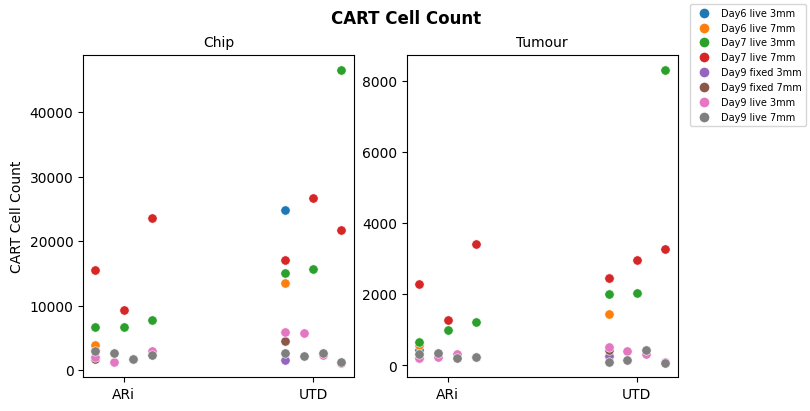

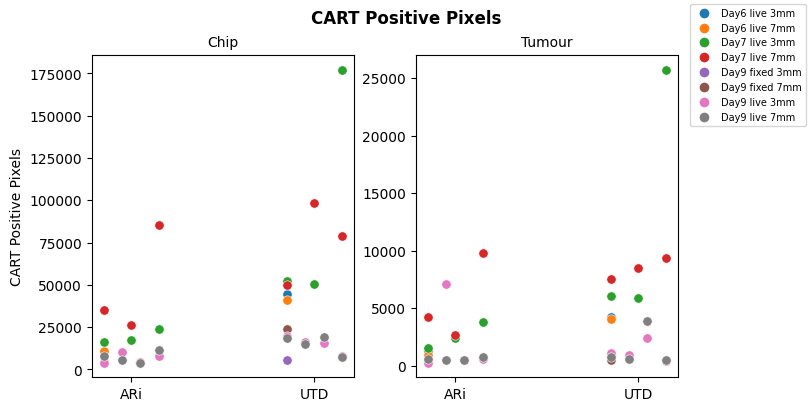

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CART cells in chip & tumour — by day + fixation + flow
# ══════════════════════════════════════════════════════════════════════════════
cart = all_results[
    (all_results["cell_type"] == "CART cells") &
    (all_results["region"].isin(["chip", "tumour"])) &
    (all_results["day"] != "unknown")
].copy()

cart["condition"] = "Day" + cart["day"] + " " + cart["fixation"] + " " + cart["flow"]

# Sort conditions logically
cart["_sort"] = cart["day"].astype(int) * 100 + cart["fixation"].map({"fixed": 0, "live": 1}) * 10 + cart["flow"].map({"3mm": 0, "7mm": 1})
cart = cart.sort_values("_sort")
cond_order = cart["condition"].unique()

metrics = [("cell_count", "CART Cell Count"), ("positive_pixels", "CART Positive Pixels")]
regions = ["chip", "tumour"]
experiments = ["fixed", "live"]

# Colour by condition (day + fixation + flow)
cond_colors = dict(zip(cond_order, plt.cm.tab10.colors[:len(cond_order)]))

for metric, ylabel in metrics:
    fig, axes = plt.subplots(1, len(regions), figsize=(8, 4),
                             sharey=False, constrained_layout=True)
    fig.suptitle(ylabel, fontsize=12, fontweight="bold")

    for ax, region in zip(axes, regions):
        sub = cart[cart["region"] == region]

        for exp_idx, exp in enumerate(experiments):
            exp_data = sub[sub["experiment"] == exp]
            for cond in cond_order:
                mask = exp_data["condition"] == cond
                vals = exp_data.loc[mask, metric].values
                jitter = np.linspace(-0.15, 0.15, max(len(vals), 1))
                for j, v in enumerate(vals):
                    ax.scatter(exp_idx + jitter[j], v, color=cond_colors[cond], s=45,
                               edgecolor="white", linewidth=0.4, zorder=3)

        ax.set_xticks(range(len(experiments)))
        ax.set_xticklabels(experiments, fontsize=10)
        ax.set_title(region.replace("_", " ").title(), fontsize=10)
        ax.set_ylabel(ylabel if ax is axes[0] else "")

    from matplotlib.lines import Line2D
    handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=cond_colors[c],
                       markersize=8, label=c) for c in cond_order]
    fig.legend(handles=handles, loc="outside right upper", fontsize=7, ncol=1)
    plt.savefig(f"CART_{metric}_by_condition.png", dpi=150, bbox_inches="tight")
    plt.show()